# Sprint 3 — PLN para alertas e estado operacional

Este notebook executa a geração de narrativas para três níveis de urgência, a classificação supervisionada de eventos, a avaliação F1/ROUGE/checklist e um relatório operacional rastreável. Os dados são sintéticos e reproduzíveis.

## Preparação

No Colab, clone ou envie a pasta completa do projeto. As dependências centrais são leves. Se necessário, execute `%pip install pandas scikit-learn matplotlib`.

In [1]:
from pathlib import Path
import sys, json

candidates = [Path.cwd(), Path.cwd().parent, Path('/content/pln_motores_rag')]
ROOT = next((p for p in candidates if (p / 'src' / 'pln_motores').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Abra o notebook na raiz do repositório ou clone o projeto em /content/pln_motores_rag.')
sys.path.insert(0, str(ROOT / 'src'))
(ROOT / 'outputs').mkdir(exist_ok=True)
print('Raiz do projeto:', ROOT)


Raiz do projeto: C:\Users\Nicolas\projects\pln_motores_rag


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from pln_motores.alerts import gerar_resumo_alerta
from pln_motores.classification import EventClassifier
from pln_motores.metrics import evaluate_rouge
from pln_motores.reports import gerar_relatorio_operacional

alerts = pd.read_csv(ROOT / 'data' / 'alertas_teste.csv')
events = pd.read_csv(ROOT / 'data' / 'eventos_rotulados.csv')
print(f'{len(alerts)} alertas e {len(events)} eventos carregados.')

30 alertas e 200 eventos carregados.


## 1. Geração de resumos textuais

Os templates variam tom, vocabulário e recomendação conforme severidade. Toda narrativa inclui alerta e sensor de origem.

In [3]:
alerts['resumo_gerado'] = [gerar_resumo_alerta(row).text for row in alerts.to_dict('records')]
examples = alerts.groupby('severidade', sort=False).head(1)[
    ['severidade', 'equipamento_id', 'sensor_id', 'resumo_gerado']
]
display(examples)

,severidade,equipamento_id,sensor_id,resumo_gerado
0,leve,Motor MT-042,TMP-042-1,Atenção: desvio leve no Motor MT-042. A temper...
1,moderado,Motor MT-017,VIB-043-2,Alerta moderado detectado no Motor MT-017. A v...
2,critico,Motor MT-105,CUR-044-1,ALERTA CRÍTICO no Motor MT-105: a corrente de ...


### Avaliação ROUGE e checklist

ROUGE compara os textos com referências redigidas manualmente. O checklist automático verifica clareza operacional, precisão de identificadores, utilidade e rastreabilidade. Uma revisão humana continua necessária.

In [4]:
rouge = evaluate_rouge(alerts['resumo_gerado'].tolist(), alerts['resumo_referencia'].tolist())
check_rows = []
for row in alerts.to_dict('records'):
    text = row['resumo_gerado']
    check_rows.append({
        'alert_id': row['alert_id'],
        'clareza': len(text.split()) <= 75 and '.' in text,
        'precisao': row['equipamento_id'] in text and row['sensor_id'] in text,
        'utilidade': any(t in text.lower() for t in ['verificar', 'acompanhar', 'inspecionar', 'parada', 'isolar']),
        'rastreabilidade': '[Fonte:' in text,
    })
check_df = pd.DataFrame(check_rows)
checklist = check_df.drop(columns='alert_id').mean().to_dict()
display(pd.DataFrame({'ROUGE': rouge}), pd.DataFrame({'Checklist': checklist}))

,ROUGE
rouge1,0.418810
rouge2,0.245530
rougeL,0.386026


,Checklist
clareza,1.0
precisao,1.0
utilidade,0.8
rastreabilidade,1.0


## 2. Classificação textual de eventos

O classificador é ajustado sobre TF-IDF de unigramas/bigramas e regressão logística balanceada. A separação holdout é estratificada e fixada por semente.

,F1
manutenção corretiva,1.0
manutenção preventiva,1.0
anomalia elétrica,1.0
anomalia mecânica,1.0
operação normal,1.0


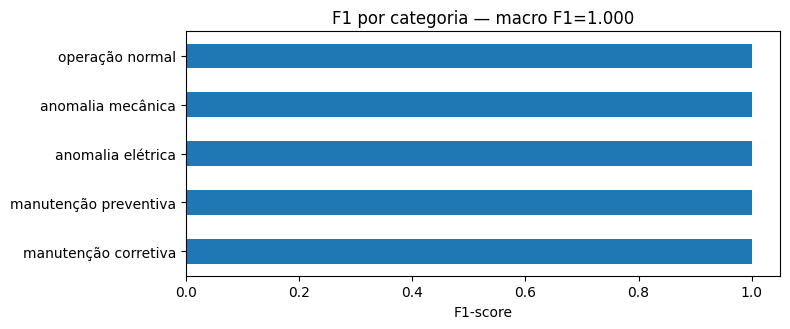

In [5]:
classifier = EventClassifier(random_state=42)
result = classifier.evaluate_holdout(events, test_size=0.25)
f1_table = pd.Series(result.per_category_f1, name='F1').sort_values()
display(f1_table.to_frame())
ax = f1_table.plot.barh(figsize=(8, 3.4), xlim=(0, 1.05), title=f'F1 por categoria — macro F1={result.macro_f1:.3f}')
ax.set_xlabel('F1-score')
plt.tight_layout()
plt.show()

## 3. Relatório operacional rastreável

Cada afirmação factual inclui alerta, sensor, valor e timestamp. As recomendações são preliminares.

In [6]:
report = gerar_relatorio_operacional(alerts.to_dict('records'), periodo='semanal')
display(Markdown(report.replace('\n\n', '\n\n')))
alerts.to_csv(ROOT / 'outputs' / 'alertas_com_resumos.csv', index=False, encoding='utf-8-sig')
(ROOT / 'outputs' / 'relatorio_operacional.txt').write_text(report, encoding='utf-8')

Relatório operacional semanal — 18/08/2026 a 23/08/2026.

Foram emitidos 30 alertas: 10 leves, 10 moderados e 10 críticos. [Fonte: ALT-0003; sensor CUR-044-1; valor 452 A; 2026-08-18T14:00:00-03:00]

O equipamento com maior concentração de risco foi Motor MT-017, com 10 eventos moderados ou críticos. [Fonte: ALT-0002; sensor VIB-043-2; valor 4.5 mm/s RMS; 2026-08-18T10:00:00-03:00]

A tendência predominante envolveu temperatura do enrolamento, presente em 6 ocorrências. [Fonte: ALT-0026; sensor TMP-043-2; valor 88°C; 2026-08-22T10:00:00-03:00]

Recomendação preliminar: priorizar a inspeção do Motor MT-105 e validar corrente de fase antes de ampliar a carga. [Fonte: ALT-0003; sensor CUR-044-1; valor 452 A; 2026-08-18T14:00:00-03:00]

As recomendações são preliminares e não substituem procedimentos de segurança nem diagnóstico em campo.

846

## 4. Síntese dos resultados e limites

- O conjunto sintético balanceado é adequado à demonstração, mas tende a superestimar o F1.
- ROUGE mede sobreposição lexical e não substitui revisão humana de segurança/clareza.
- Antes de produção, os templates, limites e rótulos devem ser validados com operadores e engenharia de manutenção.

In [7]:
summary = {
    'rouge': rouge,
    'checklist': checklist,
    'macro_f1': result.macro_f1,
    'weighted_f1': result.weighted_f1,
    'f1_por_categoria': result.per_category_f1,
}
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "rouge": {
    "rouge1": 0.4188099931727674,
    "rouge2": 0.24552951488604696,
    "rougeL": 0.3860257624754967
  },
  "checklist": {
    "clareza": 1.0,
    "precisao": 1.0,
    "utilidade": 0.8,
    "rastreabilidade": 1.0
  },
  "macro_f1": 1.0,
  "weighted_f1": 1.0,
  "f1_por_categoria": {
    "manutenção corretiva": 1.0,
    "manutenção preventiva": 1.0,
    "anomalia elétrica": 1.0,
    "anomalia mecânica": 1.0,
    "operação normal": 1.0
  }
}
